In [1]:
import pandas as pd
import numpy as np
# from tqdm import tqdm
# ============================================================
# 1. Cargar dataset
# ============================================================
# SAVE_DIR = "/content/drive/MyDrive/KYUTECH/Lab research/Research/Anomaly Detection ADCS/Coding/dataset/windowed/"
SAVE_DIR = "./dataset_windows20/"

X = np.load(SAVE_DIR + "X_windows.npy")     # shape: (N, 20, num_features)
y_bin = np.load(SAVE_DIR + "y_binary.npy")  # shape: (N,)
y_ch  = np.load(SAVE_DIR + "y_channel.npy") # shape: (N,), 0 = no fault, 1..18 canal

N, W, F = X.shape

print("=====================================")
print(" Dataset loaded successfully ")
print("=====================================")
print(f"Total windows: {N}")
print(f"Window size: {W}")
print(f"Number of features: {F}")
print(f"Anomalous windows: {sum(y_bin)}")
print(f"Nominal windows: {N - sum(y_bin)}")
print(f"Percentage anomalies: {100 * sum(y_bin)/N:.2f}%")
print("=====================================\n")

 Dataset loaded successfully 
Total windows: 399982
Window size: 20
Number of features: 20
Anomalous windows: 274971
Nominal windows: 125011
Percentage anomalies: 68.75%



In [2]:
import numpy as np

idx_nom = np.where(y_bin == 0)[0]
idx_anom = np.where(y_bin == 1)[0]

print("Nominal windows:", len(idx_nom))
print("Anomalous windows:", len(idx_anom))


Nominal windows: 125011
Anomalous windows: 274971


In [3]:
## Preprocessing

In [4]:
# separar nominales
X_nom = X[y_bin == 0]   # (N_nom, 20, num_features)
# calcular μ y σ por feature
mean_feat = X_nom.mean(axis=(0,1))   # (num_features,)
std_feat  = X_nom.std(axis=(0,1)) + 1e-8
# escalar TODO el dataset
def scale_windows(X, mean, std):
    return (X - mean[None,None,:]) / std[None,None,:]

X_scaled = scale_windows(X, mean_feat, std_feat)


In [5]:
# Balancing dataset
np.random.seed(42)

n_target = len(idx_nom)

idx_anom_sub = np.random.choice(
    idx_anom,
    size=n_target,
    replace=False
)

idx_bal = np.concatenate([idx_nom, idx_anom_sub])
np.random.shuffle(idx_bal)

X_bal = X[idx_bal]
y_bin_bal = y_bin[idx_bal]
y_ch_bal = y_ch[idx_bal]

print("Balanced dataset:")
print("X:", X_bal.shape)
print("Binary labels:", np.bincount(y_bin_bal))


Balanced dataset:
X: (250022, 20, 20)
Binary labels: [125011 125011]


In [8]:
# def variance_based_detector(window, threshold_std=1.0):
#     """
#     window: numpy array (20 x F)
#     Detecta anomalía si algún canal tiene std > threshold
#     """
#     stds = np.std(window, axis=0)
#     return 1 if np.any(stds > threshold_std) else 0
# def adaptive_variance_detector(window, k=1.0):
#     stds = np.std(window, axis=0)
#     mu = np.mean(stds)
#     sigma = np.std(stds)
#     return 1 if np.any(stds > mu + k * sigma) else 0
import pywt
import numpy as np

def extract_wavelet_features(X, wavelet="db4", level=3):
    if X.ndim == 2:
        X = X[..., np.newaxis]

    N, W, F = X.shape
    feats = []

    for i in range(N):
        feat_ch = []
        for ch in range(F):
            coeffs = pywt.wavedec(X[i,:,ch], wavelet, level=level)
            A = coeffs[0]
            Ds = coeffs[1:]

            # Energía
            EA = np.sum(A**2)
            ED = [np.sum(d**2) for d in Ds]

            # RMS detalles
            RMSD = [np.sqrt(np.mean(d**2)) for d in Ds]

            feat_ch.extend([EA] + ED + RMSD)

        feats.append(feat_ch)

    return np.array(feats)
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    Xw, y_bin, test_size=0.3, stratify=y_bin, random_state=42
)


In [9]:
Xw = extract_wavelet_features(X_scaled)
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=0.95)
pca.fit(Xtr[ytr == 0])

Xrec = pca.inverse_transform(pca.transform(Xte))
err = np.sum((Xte - Xrec)**2, axis=1)

# Threshold (nominal)
err_nom = np.sum(
    (Xtr[ytr == 0] - pca.inverse_transform(pca.transform(Xtr[ytr == 0])))**2,
    axis=1
)

TH = np.mean(err_nom) + 3*np.std(err_nom)
y_pred_pca = (err > TH).astype(int)



/opt/conda/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [399982, 119995]

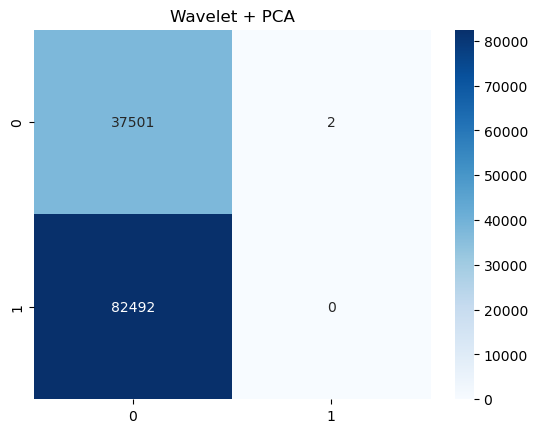

              precision    recall  f1-score   support

           0     0.3125    0.9999    0.4762     37503
           1     0.0000    0.0000    0.0000     82492

    accuracy                         0.3125    119995
   macro avg     0.1563    0.5000    0.2381    119995
weighted avg     0.0977    0.3125    0.1488    119995



In [11]:
cm = confusion_matrix(yte, y_pred_pca)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wavelet + PCA")
plt.show()

print(classification_report(yte, y_pred_pca, digits=4))


In [12]:
# One class SVM
from sklearn.svm import OneClassSVM

svm_oc = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
svm_oc.fit(Xtr[ytr == 0])

y_pred_svm = (svm_oc.predict(Xte) == -1).astype(int)

cm = confusion_matrix(yte, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wavelet + One-Class SVM")
plt.show()

print(classification_report(yte, y_pred_svm, digits=4))


ValueError: Found input variables with inconsistent numbers of samples: [399982, 119995]

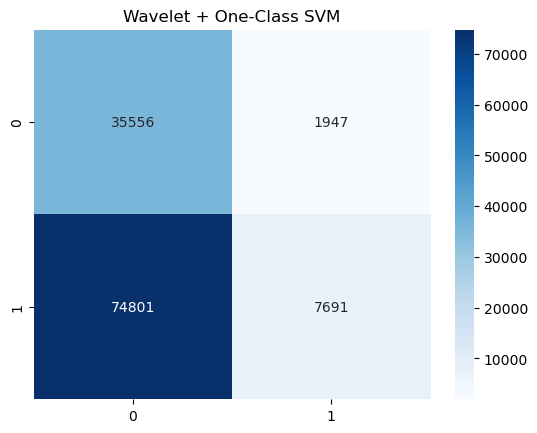

              precision    recall  f1-score   support

           0     0.3222    0.9481    0.4809     37503
           1     0.7980    0.0932    0.1670     82492

    accuracy                         0.3604    119995
   macro avg     0.5601    0.5207    0.3240    119995
weighted avg     0.6493    0.3604    0.2651    119995



In [13]:

cm = confusion_matrix(yte, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wavelet + One-Class SVM")
plt.show()

print(classification_report(yte, y_pred_svm, digits=4))

In [14]:
# PCA+SVM
pca = PCA(n_components=0.98)
Xtr_p = pca.fit_transform(Xtr)
Xte_p = pca.transform(Xte)

svm_oc = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
svm_oc.fit(Xtr_p[ytr == 0])

y_pred_pca_svm = (svm_oc.predict(Xte_p) == -1).astype(int)


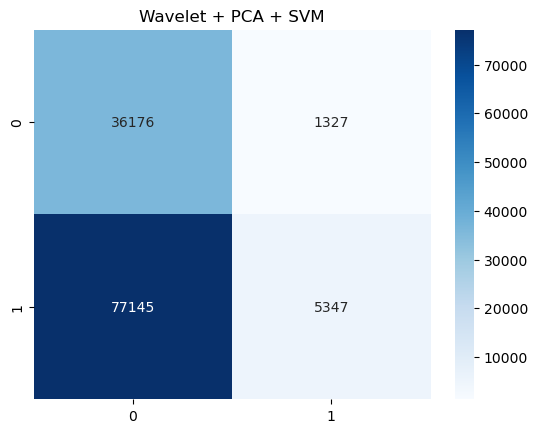

              precision    recall  f1-score   support

           0     0.3192    0.9646    0.4797     37503
           1     0.8012    0.0648    0.1199     82492

    accuracy                         0.3460    119995
   macro avg     0.5602    0.5147    0.2998    119995
weighted avg     0.6505    0.3460    0.2324    119995



In [15]:
cm = confusion_matrix(yte, y_pred_pca_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wavelet + PCA + SVM")
plt.show()

print(classification_report(yte, y_pred_pca_svm, digits=4))


In [ ]:
# Wavelet CNN
def wavelet_scalogram(X, wavelet="morl", scales=np.arange(1,21)):
    if X.ndim == 2:
        X = X[..., np.newaxis]

    scalos = []
    for i in range(X.shape[0]):
        ch_s = []
        for ch in range(X.shape[2]):
            cwt, _ = pywt.cwt(X[i,:,ch], scales, wavelet)
            ch_s.append(np.abs(cwt))
        scalos.append(np.stack(ch_s, axis=-1))
    return np.array(scalos)

Xsc = wavelet_scalogram(X)
Xtr, Xte, ytr, yte = train_test_split(
    Xsc, y_bin, test_size=0.3, stratify=y_bin, random_state=42
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=Xtr.shape[1:]),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Precision", "Recall"]
)

model.fit(Xtr, ytr, epochs=20, batch_size=64, validation_split=0.2, verbose=1)


In [ ]:
y_pred_cnn = (model.predict(Xte) > 0.5).astype(int)


In [ ]:
cm = confusion_matrix(yte, y_pred_cnn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wavelet + CNN")
plt.show()

print(classification_report(yte, y_pred_cnn, digits=4))
